In [71]:
from typing import Callable
import torch
import sys
sys.path.append('../')
from utils import DataHandler, Metric
import matplotlib.pyplot as plt
import tqdm

In [72]:
def study_filter(
    filter_list_dict: dict[str, list[Callable[[torch.Tensor], torch.Tensor]]],
    semantic_embeddings: torch.Tensor,
    num_users: int,
    metric: Metric,
    train_rate_matrix: torch.Tensor,
    test_rate_matrix: torch.Tensor
):
    (U, S, V_T) = torch.linalg.svd(semantic_embeddings, full_matrices=False)
    U_user = U[:num_users, :]
    U_item = U[num_users:, :]
    fig, ax = plt.subplots()
    for filter_name, filter_list in filter_list_dict.items():
        primary_metric_list = []
        for filter_func in tqdm.tqdm(filter_list):
            filtered_S = filter_func(S)
            metric_value = metric.eval(
                train_matrix=train_rate_matrix,
                pred_matrix=U_user * filtered_S @ (U_item * filtered_S).T,
                test_matrix=test_rate_matrix
            )
            primary_metric_list.append(metric_value["Recall@20"])
        ax.plot(range(len(filter_list)), primary_metric_list, label=filter_name)
    ax.legend()

100%|██████████| 101/101 [00:02<00:00, 39.92it/s]


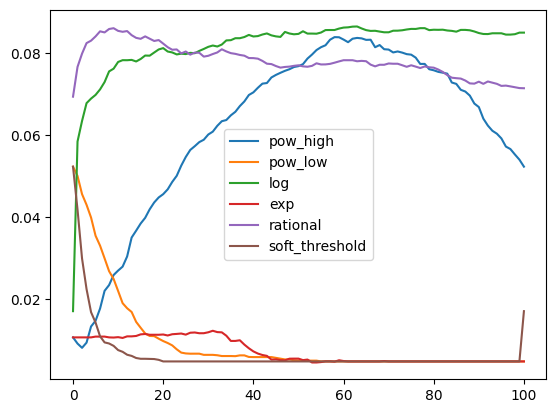

In [ ]:
datahandler = DataHandler(
    interaction_data="games",
    semantic_data="qwen",
)

filter_pow_high_list = [lambda S, p=p: torch.pow(S, p) for p in [i * 0.01 for i in range(0, 101)]]


# 1) p > 1：更强调大奇异值
filter_pow_low_list = [
    lambda S, p=p: torch.pow(S, p)
    for p in [1.0 + i * 0.02 for i in range(0, 101)]
]


# 2) log 压缩：温和压缩头部大奇异值
filter_log_list = [
    lambda S, a=a: torch.log1p(a * (S / (S.max())))
    for a in [i * 0.4 for i in range(0, 101)]
]

# 8) exp(aS): 更强地强调大奇异值
# 这里实际用的是 exp(a * (S / S.max()))
filter_exp_list = [
    lambda S, a=a: torch.exp(a * (S/(S.max())))
    for a in [i * 0.08 for i in range(0, 101)]
]


# 3) rational shrink：平滑压缩大奇异值
filter_rational_list = [
    lambda S, b=b: (S / (S.max())) / ((S / (S.max())) + b)
    for b in [0.01 + i * 0.01 for i in range(0, 101)]
]

# 4) soft threshold：逐步砍掉小奇异值
filter_soft_threshold_list = [
    lambda S, t=t: torch.clamp(S / (S.max()) - t, min=0.0)
    for t in [i * 0.01 for i in range(0, 101)]
]



# 如果你想统一管理，可以顺手放一个 dict
filter_list_dict = {
    "pow_high": filter_pow_high_list,
    "pow_low": filter_pow_low_list,
    "log": filter_log_list,
    "exp": filter_exp_list,
    "rational": filter_rational_list,
    "soft_threshold": filter_soft_threshold_list,
}
"""
study_filter(
    filter_list_dict=filter_list_dict,
    semantic_embeddings=torch.cat([datahandler.user_semantic_embeddings, datahandler.item_semantic_embeddings], dim=0),
    num_users=datahandler.num_users,
    metric=Metric(device='cuda'),
    train_rate_matrix=datahandler.rate_matrix,
    test_rate_matrix=datahandler.test_rate_matrix
)
"""

In [ ]:
from dataclasses import dataclass
from typing import Literal
import torch.nn as nn
import torch.nn.functional as F
from models import TrainableModelBase
from utils import train_model


class SFilterMLP(TrainableModelBase):
    @dataclass
    class ModelConfig(TrainableModelBase.ModelConfig):
        rank: int | None = 256
        hidden_dim: int = 64
        num_layers: int = 3
        dropout: float = 0.0
        similarity: Literal['dot', 'cos'] = 'dot'

    def __init__(
        self,
        semantic_embeddings: torch.Tensor,
        num_users: int,
        rate_matrix: torch.Tensor,
        model_config: ModelConfig,
        loss_config: TrainableModelBase.LossConfig,
    ):
        super().__init__(model_config=model_config, loss_config=loss_config)

        self.device = self.model_config.device
        self.rate_matrix = rate_matrix.to(self.device)
        self.num_users = num_users
        self.num_items = rate_matrix.shape[1]

        semantic_embeddings = semantic_embeddings.to(self.device)
        U, S, _ = torch.linalg.svd(semantic_embeddings, full_matrices=False)

        max_rank = S.shape[0]
        self.rank = max_rank if self.model_config.rank is None else min(self.model_config.rank, max_rank)

        self.register_buffer('user_basis', U[:self.num_users, :self.rank].contiguous())
        self.register_buffer('item_basis', U[self.num_users:, :self.rank].contiguous())
        self.register_buffer('base_singular_values', S[:self.rank].contiguous())

        layers = []
        in_dim = 1
        for _ in range(max(self.model_config.num_layers - 1, 0)):
            layers.append(nn.Linear(in_dim, self.model_config.hidden_dim))
            layers.append(nn.GELU())
            if self.model_config.dropout > 0:
                layers.append(nn.Dropout(self.model_config.dropout))
            in_dim = self.model_config.hidden_dim
        layers.append(nn.Linear(in_dim, 1))
        self.filter_mlp = nn.Sequential(*layers)

        self._reset_parameters()

    def _reset_parameters(self):
        for module in self.filter_mlp:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

        last_linear = None
        for module in reversed(self.filter_mlp):
            if isinstance(module, nn.Linear):
                last_linear = module
                break

        if last_linear is not None:
            identity_bias = torch.log(torch.expm1(torch.tensor(1.0))).item()
            nn.init.zeros_(last_linear.weight)
            nn.init.constant_(last_linear.bias, identity_bias)

    def get_filtered_s(self) -> torch.Tensor:
        s_input = self.base_singular_values / self.base_singular_values.max().clamp_min(1e-12)
        gain = F.softplus(self.filter_mlp(s_input.unsqueeze(-1))).squeeze(-1)
        return self.base_singular_values * gain

    def _get_all_embeddings(self) -> tuple[torch.Tensor, torch.Tensor]:
        filtered_s = self.get_filtered_s()
        user_embedding = self.user_basis * filtered_s
        item_embedding = self.item_basis * filtered_s
        return user_embedding, item_embedding

    def forward(
        self,
        user_index: torch.Tensor,
        item_index: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        all_user_embedding, all_item_embedding = self._get_all_embeddings()
        return all_user_embedding[user_index], all_item_embedding[item_index]

    @torch.no_grad()
    def predict(self) -> torch.Tensor:
        all_user_embedding, all_item_embedding = self._get_all_embeddings()
        match self.model_config.similarity:
            case 'cos':
                all_user_embedding = F.normalize(all_user_embedding, p=2, dim=1)
                all_item_embedding = F.normalize(all_item_embedding, p=2, dim=1)
            case 'dot':
                pass
            case _:
                raise ValueError(f'Unsupported similarity: {self.model_config.similarity}')
        return all_user_embedding @ all_item_embedding.T


# 训练示例
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 复用上面已经加载好的 datahandler，避免重复占用显存
if 'datahandler' not in globals():
    datahandler = DataHandler(
        interaction_data='games',
        semantic_data='qwen',
        device=device,
    )

# 为 BPR 训练调一下采样配置
datahandler.batch_size = 4096 if device == 'cuda' else 512
datahandler.num_neg_item = 1
datahandler.use_fast_sampling = True
datahandler._train_dataloader = None

metric = Metric(k_list=[10, 20], device=device)
semantic_embeddings = torch.cat(
    [datahandler.user_semantic_embeddings, datahandler.item_semantic_embeddings],
    dim=0,
)

model = SFilterMLP(
    semantic_embeddings=semantic_embeddings,
    num_users=datahandler.num_users,
    rate_matrix=datahandler.rate_matrix,
    model_config=SFilterMLP.ModelConfig(
        device=device,
        rank=256,  # 想用全部奇异值的话改成 None
        hidden_dim=64,
        num_layers=3,
        dropout=0.0,
        similarity='dot',
    ),
    loss_config=TrainableModelBase.BPRLossConfig(
        similarity='dot',
        num_neg_item=datahandler.num_neg_item,
    ),
).to(device)

test_result = train_model(
    datahandler=datahandler,
    metric=metric,
    model=model,
    num_epochs=300,
    num_steps=20,
    patience_steps=5,
    primary_metric='NDCG@20',
    verbose=True,
    use_amp=(device == 'cuda'),
)

with torch.no_grad():
    base_s = model.base_singular_values.detach().cpu()
    learned_filtered_s = model.get_filtered_s().detach().cpu()

plt.figure(figsize=(8, 4))
plt.plot(base_s.numpy(), label='base S')
plt.plot(learned_filtered_s.numpy(), label='learned filtered S')
plt.legend()
plt.title('Learned spectral filter')
plt.show()

test_result
